<h2>Лабораторна робота №1 “Linear Regression”</h2>

In [3]:
import matplotlib.pyplot as plt
import numpy as np

<h3>1. Викачати дані </h3>

In [12]:
def load(filepath):
    data = np.genfromtxt(filepath, delimiter= ',', skip_header = 1)
    x = data[:, 1]
    y = data[:, 2]
    return x,y

x_train, y_train = load("lab_1_train.csv")
x_test, y_test = load ("lab_1_test.csv")


print("Length x_train:", len(x_train), "Shape:", x_train.shape)
print("Length y_train:", len(y_train), "Shape:", y_train.shape)

Length x_train: 60 Shape: (60,)
Length y_train: 60 Shape: (60,)


<h3>2. Реалізувати лінійну регресію </h3>
яка за допомогою даних з колонки “x” прогнозує значення в колонці “y”. Тренування алгоритму повинно відбуватись лише на даних з train датасету. Test датасет слугує для перевірки якості вже натренованої моделі.


<ul>
    <li>a Візуалізувати дані з lab1_train.csv.</li>
</ul>

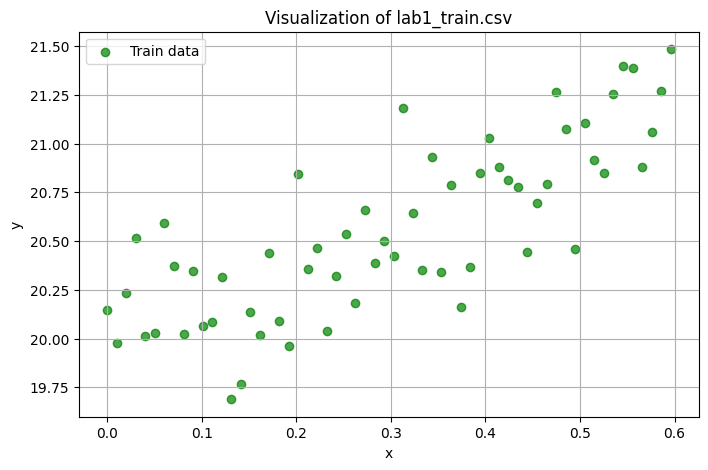

In [16]:
plt.figure(figsize = (8,5))
plt.scatter(x_train, y_train, color='green', alpha=0.7, label='Train data')
plt.title('Visualization of lab1_train.csv')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

<ul>
    <li>b Після кожної епохи виводити поточні значення ваг та функції втрат. Використовувати Mean Squared Error як функцію втрат.
</li>
</ul>

In [29]:
w = 0.0
b = 0.0
learning_rate = 0.05
epochs = 1000
tolerans = 1e-5

N = len(x_train)
prev_mse = float('inf')

for epoch in range(1, 1 + epochs):
    y_pred = w * x_train + b
    mse = np.mean((y_pred - y_train) ** 2)

    print(f"Epoch: {epoch:4d} || w: {w:.6f} || b: {b:.6f} || MSE: {mse:.6f}")

    if abs(prev_mse - mse) < tolerans:
        break
    prev_mse = mse

    dw = (2 / N) * np.sum((y_pred - y_train) * x_train)
    db = (2 / N) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    

Epoch:    1 || w: 0.000000 || b: 0.000000 || MSE: 422.477402
Epoch:    2 || w: 0.618391 || b: 2.054956 || MSE: 335.398179
Epoch:    3 || w: 1.168165 || b: 3.885990 || MSE: 266.288145
Epoch:    4 || w: 1.656814 || b: 5.517539 || MSE: 211.439177
Epoch:    5 || w: 2.091012 || b: 6.971371 || MSE: 167.908363
Epoch:    6 || w: 2.476704 || b: 8.266883 || MSE: 133.360090
Epoch:    7 || w: 2.819189 || b: 9.421350 || MSE: 105.940720
Epoch:    8 || w: 3.123183 || b: 10.450165 || MSE: 84.179136
Epoch:    9 || w: 3.392892 || b: 11.367040 || MSE: 66.907798
Epoch:   10 || w: 3.632059 || b: 12.184191 || MSE: 53.200102
Epoch:   11 || w: 3.844021 || b: 12.912500 || MSE: 42.320655
Epoch:   12 || w: 4.031751 || b: 13.561663 || MSE: 33.685824
Epoch:   13 || w: 4.197895 || b: 14.140315 || MSE: 26.832410
Epoch:   14 || w: 4.344813 || b: 14.656151 || MSE: 21.392804
Epoch:   15 || w: 4.474606 || b: 15.116025 || MSE: 17.075254
Epoch:   16 || w: 4.589146 || b: 15.526045 || MSE: 13.648215
Epoch:   17 || w: 4.6901

<ul>
    <li>c Після того, як градієнтний спуск зійшовся, порахувати функцію втрат на тестових даних з lab1_test.csv.</li>
</ul>

In [30]:
y_test_pred = w * x_test + b
mse_test = np.mean((y_test_pred - y_test) ** 2)

print(f" w: {w:.6f} || b: {b:.6f} || MSE: {mse_test:.6f}")

 w: 2.218972 || b: 19.886290 || MSE: 0.079663


<ul>
    <li>d Візуалізувати на одному графіку дані з lab1_train.csv,  lab1_test.csv та лінію, до якої зійшовся розв’язок.</li>
</ul>

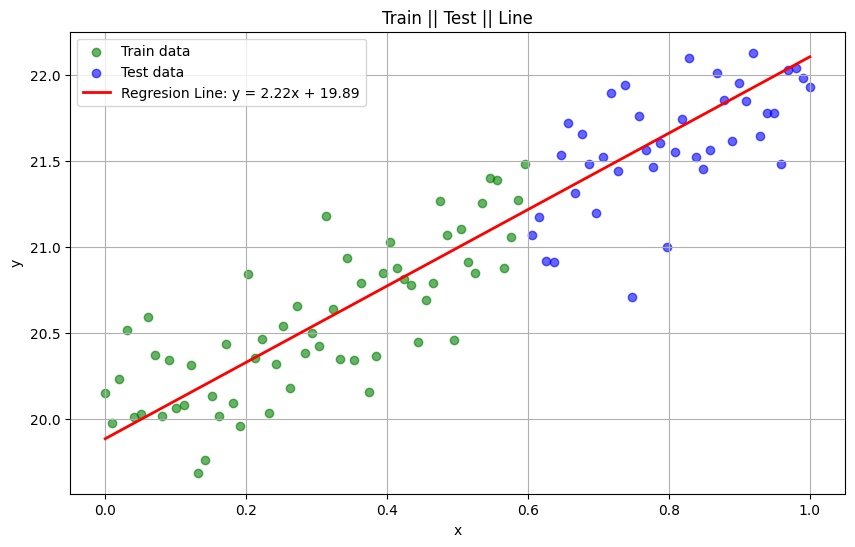

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, color='green', alpha=0.6, label='Train data')
plt.scatter(x_test, y_test, color='blue', alpha=0.6, label='Test data')

x_combined = np.concatenate([x_train, x_test])
x_line = np.linspace(np.min(x_combined), np.max(x_combined), 100)
y_line = w * x_line + b

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Regresion Line: y = {w:.2f}x + {b:.2f}')
plt.title('Train || Test || Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()